# Highway RL Experiments

Comparison of PPO, DQN, and A2C across highway-v0, roundabout-v0, and intersection-v0 environments with hyperparameter tuning and recorded video outputs.

# Overview:

This project evaluates DQN, PPO, and A2C algorithms across three environments: highway-v0 , roundabout-v0 , and intersection-v0. It performs extensive hyperparameter tuning to find the optimal settings for driving tasks.

# Initial Hypothesis:

I expect PPO to achieve the highest rewards in the intersection and roundabout environments because its clipped surrogate objective prevents policy collapse, where the agent suddenly becomes random or unstable. A2C will likely train the fastest due to its synchronous updates but may show higher variance. DQN is expected to perform well on the straight highway but might struggle with the complex coordination required for the roundabout due to its reliance on a Q-table/Value-function approximation in highly dynamic states.

## Installing and Importing Required Libraries

installs Gymnasium and highway-env, along with the Stable-Baselines3 library, using these pre-implemented frameworks to focus on conducting a systematic comparison of RL algorithms.

In [2]:
# mounting my Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Installing required packages for Colab
import subprocess
import sys

print("Installing required packages...")
packages = [
    "gymnasium[alldeps]",
    "highway-env",
    "stable-baselines3[extra]",
    "torch",
    "numpy",
    "pillow",
    "imageio" ]

# Looping through the package list and installing them
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    except Exception as e:
        print(f"Notice: Issue installing {package}. It may already be present.")

print("Installation complete!")

Installing required packages...
Installation complete!


In [4]:
# Importing necessary libraries for reinforcement learning and visualization
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import highway_env
import imageio
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.callbacks import CheckpointCallback
from typing import Tuple, Optional
from IPython.display import Image, display
from PIL import Image as PILImage
import io
import warnings

# Suppressing warning messages for a cleaner output
warnings.filterwarnings('ignore')
# Setting working directory to the project folder on my Google Drive
thisdir = '/content/drive/MyDrive/defaultproject'
if not os.path.exists(thisdir):
    os.makedirs(thisdir)
os.chdir(thisdir)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


All libraries imported successfully! Working directory: /content/drive/MyDrive/defaultproject


## Highway-v0: PPO,A2C,DQN Training

In [4]:
# Defining environment and total training steps
ENV_NAME = "highway-v0"
TOTAL_TIMESTEPS = 25000
algorithms = {
    "PPO": PPO,
    "A2C": A2C,
    "DQN": DQN}

# Creating environment without rendering to maximize speed
env = gym.make(ENV_NAME)

# Looping through each algorithm to train them sequentially
for algo_name, algo_class in algorithms.items():
    SAVE_PATH = f"/content/drive/MyDrive/defaultproject/baseline_checkpoints/{algo_name.lower()}_{ENV_NAME.replace('-', '_')}"
    CHECKPOINT_DIR = f"/content/drive/MyDrive/defaultproject/checkpoints/{algo_name.lower()}_{ENV_NAME.replace('-', '_')}"

    # Checking if the final model is already fully trained
    if os.path.exists(SAVE_PATH + ".zip"):
        print(f"{algo_name} is completely trained. Skipping to next...")
        continue

    # Searching for mid-training backups in case Colab crashed earlier
    latest_checkpoint = None
    steps_completed = 0
    if os.path.exists(CHECKPOINT_DIR):
        checkpoints = glob.glob(f"{CHECKPOINT_DIR}/{algo_name}_backup_*_steps.zip")
        if checkpoints:
            latest_checkpoint = max(checkpoints, key=os.path.getctime)
            try:
                steps_completed = int(latest_checkpoint.split('_')[-2])
            except:
                steps_completed = 0

    # Deciding to resume from a backup OR start fresh
    if latest_checkpoint and steps_completed > 0 and steps_completed < TOTAL_TIMESTEPS:
        print(f"\nCrash detected! Resuming {algo_name} from step {steps_completed}...")
        model = algo_class.load(latest_checkpoint, env=env)
        remaining_steps = TOTAL_TIMESTEPS - steps_completed
        print(f"Training the remaining {remaining_steps} steps...")
    else:
        print(f"\nInitializing fresh {algo_name} Agent on GPU...")
        model = algo_class("MlpPolicy", env, verbose=1)
        remaining_steps = TOTAL_TIMESTEPS
        print(f"Training from start ({TOTAL_TIMESTEPS} steps)...")

    # Creating a checkpoint callback to save the model every 5,000 steps
    checkpoint_callback = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR,
        name_prefix=f"{algo_name}_backup")

    # Executing the training phase
    model.learn(total_timesteps=remaining_steps, callback=checkpoint_callback, reset_num_timesteps=False)

    # Saving the final, fully trained model to Google Drive
    model.save(SAVE_PATH)
    print(f"{algo_name} full training complete and saved to Drive!")
env.close()

Streaming output truncated to the last 5000 lines.
|    n_updates        | 3009     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 8.75     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1200     |
|    fps              | 2        |
|    time_elapsed     | 4749     |
|    total_timesteps  | 12184    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.271    |
|    n_updates        | 3020     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10.4     |
|    ep_rew_mean      | 9.07     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1204     |
|    fps              | 2        |
|    time_elapsed     | 4768     |
|    total_timesteps  | 12234    |
| tr

## Highway MP4 Videos

In [5]:
from IPython.display import Video
import json

# Setting up the evaluation environment for Highway
ENV_NAME_HIGHWAY = "highway-v0"
algorithms_highway = ["PPO", "A2C", "DQN"]
eval_env_highway = gym.make(ENV_NAME_HIGHWAY, render_mode="rgb_array")

# Initializing unique dictionaries to strictly store Highway metrics
highway_rewards = {}
highway_steps = {}

# Looping through each trained algorithm to evaluate and record its performance
for algo_name in algorithms_highway:
    MODEL_PATH = f"/content/drive/MyDrive/defaultproject/baseline_checkpoints/{algo_name.lower()}_{ENV_NAME_HIGHWAY.replace('-', '_')}"
    VIDEO_PATH = f"/content/drive/MyDrive/defaultproject/baseline_videos/{algo_name.lower()}_highway_video.mp4"
    if not os.path.exists(MODEL_PATH + ".zip"):
        print(f"Missing model for {algo_name}. Skipping...")
        continue

    print(f"\nRecording {algo_name} on Highway...")
    # Loading specific model based on the algorithm name
    if algo_name == "PPO":
        loaded_model = PPO.load(MODEL_PATH, env=eval_env_highway)
    elif algo_name == "A2C":
        loaded_model = A2C.load(MODEL_PATH, env=eval_env_highway)
    elif algo_name == "DQN":
        loaded_model = DQN.load(MODEL_PATH, env=eval_env_highway)

    # Resetting the environment to start a fresh evaluation episode
    obs, info = eval_env_highway.reset()
    frames = []
    total_reward = 0
    episode_steps = 0
    done = truncated = False
    # Running the episode until the car crashes or finishes the scenario
    while not (done or truncated):
        # Predicting the best action deterministically
        action, _ = loaded_model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env_highway.step(action)
        total_reward += reward
        episode_steps += 1

        # Capturing the visual frame for the video
        frame = eval_env_highway.render()
        if frame is not None:
            frames.append(frame)
    # Saving to Google Drive
    imageio.mimsave(VIDEO_PATH, frames, fps=15, macro_block_size=None)
    print(f"{algo_name} Reward: {round(total_reward, 2)} | Survived: {episode_steps} steps")
    highway_rewards[algo_name] = total_reward
    highway_steps[algo_name] = episode_steps
    # Displaying the inline video
    display(Video(VIDEO_PATH, embed=True))
eval_env_highway.close()

# Packaging metrics together to prevent data loss in case Colab disconnects
metrics_to_save = {
    "rewards": highway_rewards,
    "steps": highway_steps}
# Saving them as a text file directly to Google Drive
METRICS_PATH = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_highway.json"
with open(METRICS_PATH, "w") as outfile:
    json.dump(metrics_to_save, outfile)
print(f"\nHighway MP4 Videos complete! Metrics backed up to {METRICS_PATH}")


Recording PPO on Highway...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
PPO Reward: 29.36 | Survived: 40 steps



Recording A2C on Highway...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
A2C Reward: 4.77 | Survived: 6 steps



Recording DQN on Highway...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DQN Reward: 9.04 | Survived: 10 steps



Highway MP4 Videos complete! Metrics backed up to /content/drive/MyDrive/defaultproject/metrics_highway.json


## Highway- Chart Analysis

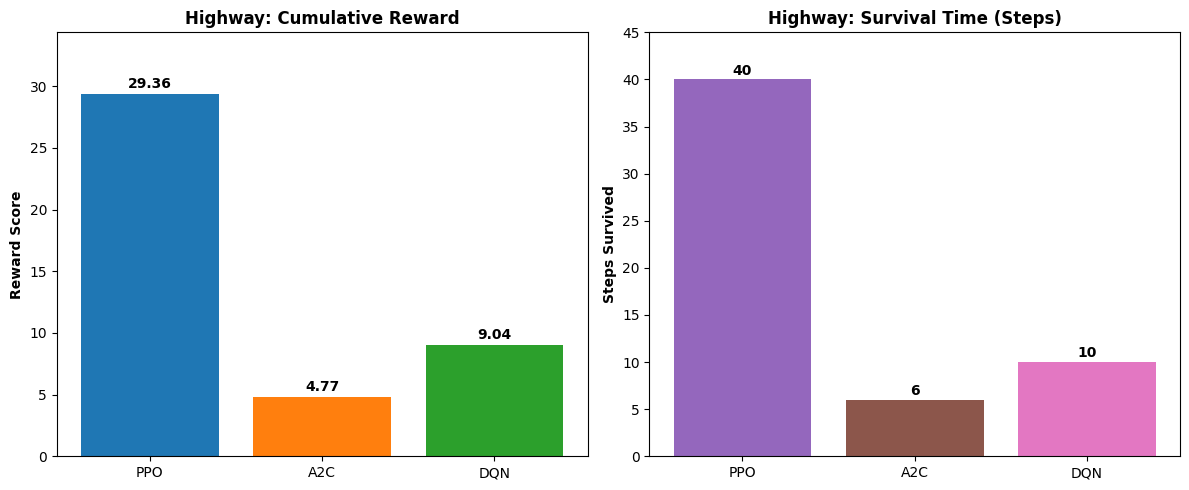

Highway Analysis Charts safely generated and saved to /content/drive/MyDrive/defaultproject/chart_dual_highway.png


In [6]:
import matplotlib.pyplot as plt

# Providing a safety net to load metrics from Drive if Colab RAM was wiped
METRICS_PATH = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_highway.json"
if 'highway_rewards' not in locals() or not highway_rewards:
    print("Loading Baseline metrics from Drive...")
    with open(METRICS_PATH, "r") as infile:
        loaded_data = json.load(infile)
        highway_rewards = loaded_data["rewards"]
        highway_steps = loaded_data["steps"]

# Extracting algorithm names and their corresponding metrics
algos_highway_list = list(highway_rewards.keys())
rewards_highway_list = list(highway_rewards.values())
steps_highway_list = list(highway_steps.values())

fig_h, (ax1_h, ax2_h) = plt.subplots(1, 2, figsize=(12, 5))

# Plotting Cumulative Reward
ax1_h.bar(algos_highway_list, rewards_highway_list, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1_h.set_title('Highway: Cumulative Reward', fontweight='bold')
ax1_h.set_ylabel('Reward Score', fontweight='bold')
if rewards_highway_list:
    ax1_h.set_ylim(0, max(rewards_highway_list) + 5)
for i, v in enumerate(rewards_highway_list):
    ax1_h.text(i, v + 0.5, str(round(v, 2)), ha='center', fontweight='bold')

# Plotting Survival Time
ax2_h.bar(algos_highway_list, steps_highway_list, color=['#9467bd', '#8c564b', '#e377c2'])
ax2_h.set_title('Highway: Survival Time (Steps)', fontweight='bold')
ax2_h.set_ylabel('Steps Survived', fontweight='bold')
if steps_highway_list:
    ax2_h.set_ylim(0, max(steps_highway_list) + 5)
for i, v in enumerate(steps_highway_list):
    ax2_h.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()

# Saving to Google Drive
CHART_PATH_HIGHWAY = f"/content/drive/MyDrive/defaultproject/baseline_charts/chart_dual_highway.png"
plt.savefig(CHART_PATH_HIGHWAY)
plt.show()
print(f"Highway Analysis Charts safely generated and saved to {CHART_PATH_HIGHWAY}")

## Tuning highway parameters for dqn algorithm

In [7]:
# Defining unique variables for the Tuning experiment
ENV_NAME_TUNE_HWY = "highway-v0"
TOTAL_TIMESTEPS_TUNE_HWY = 25000
SAVE_PATH_TUNE_HWY = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/dqn_tuned_highway"
CHECKPOINT_DIR_TUNE_HWY = f"/content/drive/MyDrive/defaultproject/checkpoints/dqn_tuned_highway"

# Establishing the extensive hyperparameter changes
tuned_dqn_params = {
    "learning_rate": 0.0005,
    "exploration_fraction": 0.5,
    "batch_size": 256,
    "gamma": 0.8,
    "buffer_size": 100000,
    "verbose": 1}

# Creating the training environment
env_tune_hwy = gym.make(ENV_NAME_TUNE_HWY)

# Checking if the tuned model is already fully trained
if os.path.exists(SAVE_PATH_TUNE_HWY + ".zip"):
    print("Tuned DQN is completely trained for Highway. Skipping to evaluation...")
else:
    # Searching for mid-training backups in case Colab crashed
    latest_checkpoint_tune_hwy = None
    steps_completed_tune_hwy = 0
    if os.path.exists(CHECKPOINT_DIR_TUNE_HWY):
        checkpoints_tune_hwy = glob.glob(f"{CHECKPOINT_DIR_TUNE_HWY}/dqn_tuned_backup_*_steps.zip")
        if checkpoints_tune_hwy:
            latest_checkpoint_tune_hwy = max(checkpoints_tune_hwy, key=os.path.getctime)
            try:
                steps_completed_tune_hwy = int(latest_checkpoint_tune_hwy.split('_')[-2])
            except:
                steps_completed_tune_hwy = 0

    # Deciding to resume from a backup OR start fresh
    if latest_checkpoint_tune_hwy and steps_completed_tune_hwy > 0 and steps_completed_tune_hwy < TOTAL_TIMESTEPS_TUNE_HWY:
        print(f"\nCrash detected! Resuming Tuned DQN from step {steps_completed_tune_hwy}...")
        model_tune_hwy = DQN.load(latest_checkpoint_tune_hwy, env=env_tune_hwy)
        remaining_steps_tune_hwy = TOTAL_TIMESTEPS_TUNE_HWY - steps_completed_tune_hwy
        print(f"Training the remaining {remaining_steps_tune_hwy} steps...")
    else:
        print("\nInitializing fresh TUNED DQN Agent on GPU with aggressive exploration...")
        # Injecting new parameters directly into the algorithm
        model_tune_hwy = DQN("MlpPolicy", env_tune_hwy, **tuned_dqn_params)
        remaining_steps_tune_hwy = TOTAL_TIMESTEPS_TUNE_HWY
        print(f"Training from start ({TOTAL_TIMESTEPS_TUNE_HWY} steps)...")

    # Creating a checkpoint callback
    callback_tune_hwy = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR_TUNE_HWY,
        name_prefix="dqn_tuned_backup")

    # Executing the training phase
    model_tune_hwy.learn(total_timesteps=remaining_steps_tune_hwy, callback=callback_tune_hwy, reset_num_timesteps=False)
    model_tune_hwy.save(SAVE_PATH_TUNE_HWY)
env_tune_hwy.close()

Streaming output truncated to the last 5000 lines.
|    learning_rate    | 0.0005   |
|    loss             | 0.0327   |
|    n_updates        | 2007     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.84     |
|    ep_rew_mean      | 8.36     |
|    exploration_rate | 0.379    |
| time/               |          |
|    episodes         | 776      |
|    fps              | 2        |
|    time_elapsed     | 3132     |
|    total_timesteps  | 8167     |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0286   |
|    n_updates        | 2016     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.83     |
|    ep_rew_mean      | 8.36     |
|    exploration_rate | 0.377    |
| time/               |          |
|    episodes         | 780      |
|    fps              | 2        |
|   

## Recording the Tuned Highway Performance

In [8]:
# Setting up the evaluation environment for the Tuned model
eval_env_tune_hwy = gym.make(ENV_NAME_TUNE_HWY, render_mode="rgb_array")
VIDEO_PATH_TUNE_HWY = f"/content/drive/MyDrive/defaultproject/dqn_tuned_highway_video.mp4"

if not os.path.exists(SAVE_PATH_TUNE_HWY + ".zip"):
    print("Missing Tuned model. Please run the training cell first.")
else:
    print("\nRecording TUNED (Best Parameters) DQN on Highway...")

    # Loading the newly trained tuned model
    loaded_tuned_dqn = DQN.load(SAVE_PATH_TUNE_HWY, env=eval_env_tune_hwy)

    # Resetting the environment for a clean evaluation
    obs_th, info_th = eval_env_tune_hwy.reset()
    frames_th = []
    total_reward_th = 0
    episode_steps_th = 0
    done_th = truncated_th = False

    # Running the episode to capture the tuned performance
    while not (done_th or truncated_th):
        action_th, _ = loaded_tuned_dqn.predict(obs_th, deterministic=True)
        obs_th, reward_th, done_th, truncated_th, info_th = eval_env_tune_hwy.step(action_th)

        total_reward_th += reward_th
        episode_steps_th += 1

        frame_th = eval_env_tune_hwy.render()
        if frame_th is not None:
            frames_th.append(frame_th)

    # Saving the tuned performance video
    imageio.mimsave(VIDEO_PATH_TUNE_HWY, frames_th, fps=15, macro_block_size=None)

    print(f"Tuned DQN Reward: {round(total_reward_th, 2)} | Survived: {episode_steps_th} steps")

    # Packaging tuned metrics for the final comparison
    metrics_to_save_tune_hwy = {
        "reward": total_reward_th,
        "steps": episode_steps_th
    }

    # Saving the tuned results to a unique JSON file on Drive
    METRICS_PATH_TUNE_HWY = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_highway_tuned.json"
    with open(METRICS_PATH_TUNE_HWY, "w") as outfile_th:
        json.dump(metrics_to_save_tune_hwy, outfile_th)

    # Displaying the tuned video
    display(Video(VIDEO_PATH_TUNE_HWY, embed=True))
    print(f"Tuned MP4 Video complete! Metrics backed up to {METRICS_PATH_TUNE_HWY}")

eval_env_tune_hwy.close()


Recording TUNED (Best Parameters) DQN on Highway...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Tuned DQN Reward: 11.69 | Survived: 13 steps


Tuned MP4 Video complete! Metrics backed up to /content/drive/MyDrive/defaultproject/metrics_highway_tuned.json


## Roundabout Training Loop(PPO,A2C,DQN Algorithms)

In [11]:
# Defining unique variables for the Roundabout environment
ENV_NAME_ROUNDABOUT = "roundabout-v0"
TOTAL_TIMESTEPS_ROUNDABOUT = 25000
algorithms_roundabout = {
    "PPO": PPO,
    "A2C": A2C,
    "DQN": DQN}
# Creating training environment
env_roundabout = gym.make(ENV_NAME_ROUNDABOUT)
# Looping through each algorithm
for algo_name_roundabout, algo_class_roundabout in algorithms_roundabout.items():
    SAVE_PATH_ROUNDABOUT = f"/content/drive/MyDrive/defaultproject/baseline_checkpoints/{algo_name_roundabout.lower()}_roundabout"
    CHECKPOINT_DIR_ROUNDABOUT = f"/content/drive/MyDrive/defaultproject/checkpoints/{algo_name_roundabout.lower()}_roundabout"
    # Searching for mid-training backups
    latest_checkpoint_roundabout = None
    steps_completed_roundabout = 0
    if os.path.exists(CHECKPOINT_DIR_ROUNDABOUT):
        checkpoints_roundabout = glob.glob(f"{CHECKPOINT_DIR_ROUNDABOUT}/{algo_name_roundabout}_roundabout_backup_*_steps.zip")
        if checkpoints_roundabout:
            latest_checkpoint_roundabout = max(checkpoints_roundabout, key=os.path.getctime)
            try:
                steps_completed_roundabout = int(latest_checkpoint_roundabout.split('_')[-2])
            except:
                steps_completed_roundabout = 0

    # Resuming from a backup OR starting fresh
    if latest_checkpoint_roundabout and steps_completed_roundabout > 0 and steps_completed_roundabout < TOTAL_TIMESTEPS_ROUNDABOUT:
        print(f"\nCrash detected! Resuming {algo_name_roundabout} from step {steps_completed_roundabout}...")
        model_roundabout = algo_class_roundabout.load(latest_checkpoint_roundabout, env=env_roundabout)
        remaining_steps_roundabout = TOTAL_TIMESTEPS_ROUNDABOUT - steps_completed_roundabout
        print(f"Training the remaining {remaining_steps_roundabout} steps...")
    else:
        print(f"\nInitializing fresh {algo_name_roundabout} Agent for Roundabout...")
        model_roundabout = algo_class_roundabout("MlpPolicy", env_roundabout, verbose=1)
        remaining_steps_roundabout = TOTAL_TIMESTEPS_ROUNDABOUT
        print(f"Training from start ({TOTAL_TIMESTEPS_ROUNDABOUT} steps)...")

    # Creating a checkpoint callback
    callback_roundabout = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR_ROUNDABOUT,
        name_prefix=f"{algo_name_roundabout}_roundabout_backup")
    # Executing the training phase
    model_roundabout.learn(total_timesteps=remaining_steps_roundabout, callback=callback_roundabout, reset_num_timesteps=False)
    model_roundabout.save(SAVE_PATH_ROUNDABOUT)
    print(f"{algo_name_roundabout} full training complete for Roundabout!")
env_roundabout.close()

Streaming output truncated to the last 5000 lines.
|    n_updates        | 3558     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.93     |
|    ep_rew_mean      | 6.42     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1816     |
|    fps              | 22       |
|    time_elapsed     | 195      |
|    total_timesteps  | 14354    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0563   |
|    n_updates        | 3562     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.02     |
|    ep_rew_mean      | 6.52     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1820     |
|    fps              | 22       |
|    time_elapsed     | 196      |
|    total_timesteps  | 14371    |
| tr

## Roundabout MP4 Videos

In [12]:
eval_env_roundabout = gym.make(ENV_NAME_ROUNDABOUT, render_mode="rgb_array")
# Initializing unique dictionaries
roundabout_rewards_dict = {}
roundabout_steps_dict = {}
# Looping through each trained algorithm
for algo_name_eval_r in ["PPO", "A2C", "DQN"]:
    MODEL_PATH_EVAL_R = f"/content/drive/MyDrive/defaultproject/baseline_checkpoints/{algo_name_eval_r.lower()}_roundabout"
    VIDEO_PATH_EVAL_R = f"/content/drive/MyDrive/defaultproject/baseline_videos/{algo_name_eval_r.lower()}_roundabout_video.mp4"

    if not os.path.exists(MODEL_PATH_EVAL_R + ".zip"):
        print(f"Missing model for {algo_name_eval_r}. Skipping...")
        continue
    print(f"\nRecording {algo_name_eval_r} on Roundabout...")
    # Loading the specific model
    if algo_name_eval_r == "PPO":
        loaded_model_r = PPO.load(MODEL_PATH_EVAL_R, env=eval_env_roundabout)
    elif algo_name_eval_r == "A2C":
        loaded_model_r = A2C.load(MODEL_PATH_EVAL_R, env=eval_env_roundabout)
    elif algo_name_eval_r == "DQN":
        loaded_model_r = DQN.load(MODEL_PATH_EVAL_R, env=eval_env_roundabout)

    # Resetting the environment
    obs_r, info_r = eval_env_roundabout.reset()
    frames_r = []
    total_reward_r = 0
    episode_steps_r = 0
    done_r = truncated_r = False
    # Running the episode
    while not (done_r or truncated_r):
        action_r, _ = loaded_model_r.predict(obs_r, deterministic=True)
        obs_r, reward_r, done_r, truncated_r, info_r = eval_env_roundabout.step(action_r)
        total_reward_r += reward_r
        episode_steps_r += 1
        frame_r = eval_env_roundabout.render()
        if frame_r is not None:
            frames_r.append(frame_r)

    # Saving the collected frames
    imageio.mimsave(VIDEO_PATH_EVAL_R, frames_r, fps=15, macro_block_size=None)
    print(f"{algo_name_eval_r} Reward: {round(total_reward_r, 2)} | Survived: {episode_steps_r} steps")
    roundabout_rewards_dict[algo_name_eval_r] = total_reward_r
    roundabout_steps_dict[algo_name_eval_r] = episode_steps_r
    display(Video(VIDEO_PATH_EVAL_R, embed=True))
eval_env_roundabout.close()
# Packaging metrics together
metrics_to_save_roundabout = {
    "rewards": roundabout_rewards_dict,
    "steps": roundabout_steps_dict}

# Saving to Google Drive
JSON_PATH_ROUNDABOUT = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_roundabout.json"
with open(JSON_PATH_ROUNDABOUT, "w") as outfile_r:
    json.dump(metrics_to_save_roundabout, outfile_r)
print(f"\nRoundabout MP4 Videos complete! Metrics backed up to {JSON_PATH_ROUNDABOUT}")


Recording PPO on Roundabout...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
PPO Reward: 9.17 | Survived: 11 steps



Recording A2C on Roundabout...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
A2C Reward: 9.58 | Survived: 11 steps



Recording DQN on Roundabout...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DQN Reward: 10.08 | Survived: 11 steps



Roundabout MP4 Videos complete! Metrics backed up to /content/drive/MyDrive/defaultproject/metrics_roundabout.json


## Roundabout Chart Analysis

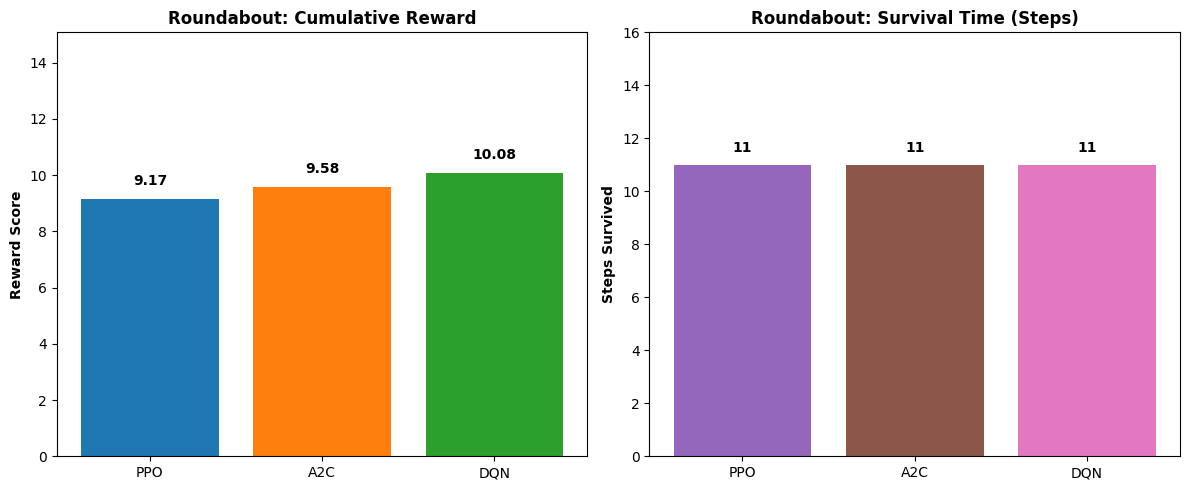

Roundabout Analysis Charts safely generated and saved to /content/drive/MyDrive/defaultproject/chart_dual_roundabout.png


In [13]:
# Providing a safety net
JSON_PATH_ROUNDABOUT = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_roundabout.json"
if 'roundabout_rewards_dict' not in locals() or not roundabout_rewards_dict:
    print("Loading Baseline metrics from Drive...")
    with open(JSON_PATH_ROUNDABOUT, "r") as infile_r:
        loaded_data_r = json.load(infile_r)
        roundabout_rewards_dict = loaded_data_r["rewards"]
        roundabout_steps_dict = loaded_data_r["steps"]

# Extracting uniquely named variables for the chart
algos_r_list = list(roundabout_rewards_dict.keys())
rewards_r_list = list(roundabout_rewards_dict.values())
steps_r_list = list(roundabout_steps_dict.values())

fig_r, (ax1_r, ax2_r) = plt.subplots(1, 2, figsize=(12, 5))
# Plotting Cumulative Reward
ax1_r.bar(algos_r_list, rewards_r_list, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1_r.set_title('Roundabout: Cumulative Reward', fontweight='bold')
ax1_r.set_ylabel('Reward Score', fontweight='bold')
if rewards_r_list:
    ax1_r.set_ylim(0, max(rewards_r_list) + 5)
for i, v in enumerate(rewards_r_list):
    ax1_r.text(i, v + 0.5, str(round(v, 2)), ha='center', fontweight='bold')

# Plotting Survival Time
ax2_r.bar(algos_r_list, steps_r_list, color=['#9467bd', '#8c564b', '#e377c2'])
ax2_r.set_title('Roundabout: Survival Time (Steps)', fontweight='bold')
ax2_r.set_ylabel('Steps Survived', fontweight='bold')
if steps_r_list:
    ax2_r.set_ylim(0, max(steps_r_list) + 5)
for i, v in enumerate(steps_r_list):
    ax2_r.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()

# Saving the chart
CHART_PATH_ROUNDABOUT = f"/content/drive/MyDrive/defaultproject/baseline_charts/chart_dual_roundabout.png"
plt.savefig(CHART_PATH_ROUNDABOUT)
plt.show()
print(f"Roundabout Analysis Charts safely generated and saved to {CHART_PATH_ROUNDABOUT}")

## Tuning Roundabout DQN algorithm

In [14]:
# Defining unique variables for the Roundabout Tuning experiment
ENV_NAME_TUNE_R = "roundabout-v0"
TOTAL_TIMESTEPS_TUNE_R = 25000
SAVE_PATH_TUNE_R = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/dqn_tuned_roundabout"
CHECKPOINT_DIR_TUNE_R = f"/content/drive/MyDrive/defaultproject/checkpoints/dqn_tuned_roundabout"

# optimized combination
tuned_r_dqn_params = {
    "learning_rate": 0.0005,
    "exploration_fraction": 0.5, # to force turning/yielding
    "batch_size": 256, #for stable learning
    "gamma": 0.9, # slightly higher than highway because roundabouts require looking ahead
    "buffer_size": 100000,
    "verbose": 1}

# Training Phase
env_tune_r = gym.make(ENV_NAME_TUNE_R)

if os.path.exists(SAVE_PATH_TUNE_R + ".zip"):
    print("Tuned Roundabout DQN is already trained. Skipping to evaluation...")
else:
    latest_checkpoint_tune_r = None
    steps_completed_tune_r = 0
    if os.path.exists(CHECKPOINT_DIR_TUNE_R):
        checkpoints_tune_r = glob.glob(f"{CHECKPOINT_DIR_TUNE_R}/dqn_tuned_roundabout_backup_*_steps.zip")
        if checkpoints_tune_r:
            latest_checkpoint_tune_r = max(checkpoints_tune_r, key=os.path.getctime)
            try:
                steps_completed_tune_r = int(latest_checkpoint_tune_r.split('_')[-2])
            except:
                steps_completed_tune_r = 0
    # checking and resuming from certain steps where it crashed
    if latest_checkpoint_tune_r and steps_completed_tune_r > 0 and steps_completed_tune_r < TOTAL_TIMESTEPS_TUNE_R:
        print(f"\nResuming Tuned Roundabout DQN from step {steps_completed_tune_r}...")
        model_tune_r = DQN.load(latest_checkpoint_tune_r, env=env_tune_r)
        remaining_steps_tune_r = TOTAL_TIMESTEPS_TUNE_R - steps_completed_tune_r
    else:
        print("\nInitializing Tuned Roundabout DQN with aggressive exploration...")
        model_tune_r = DQN("MlpPolicy", env_tune_r, **tuned_r_dqn_params)
        remaining_steps_tune_r = TOTAL_TIMESTEPS_TUNE_R
    # saving the checkpoints
    callback_tune_r = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR_TUNE_R,
        name_prefix="dqn_tuned_roundabout_backup")
    model_tune_r.learn(total_timesteps=remaining_steps_tune_r, callback=callback_tune_r, reset_num_timesteps=False)
    model_tune_r.save(SAVE_PATH_TUNE_R)
    print("Tuned Roundabout DQN training complete!")
env_tune_r.close()

Streaming output truncated to the last 5000 lines.
|    learning_rate    | 0.0005   |
|    loss             | 0.0452   |
|    n_updates        | 3168     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.06     |
|    ep_rew_mean      | 8.3      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1560     |
|    fps              | 22       |
|    time_elapsed     | 566      |
|    total_timesteps  | 12806    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0288   |
|    n_updates        | 3176     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.12     |
|    ep_rew_mean      | 8.39     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1564     |
|    fps              | 22       |
|   

## Evaluation & Video Backup

In [15]:
# Evaluation and Video Recording
eval_env_tune_r = gym.make(ENV_NAME_TUNE_R, render_mode="rgb_array")
VIDEO_PATH_TUNE_R = f"/content/drive/MyDrive/defaultproject/dqn_tuned_roundabout_video.mp4"

print("\nRecording TUNED Roundabout DQN...")
loaded_tuned_r_dqn = DQN.load(SAVE_PATH_TUNE_R, env=eval_env_tune_r)
# resetting the environment
obs_tr, info_tr = eval_env_tune_r.reset()
frames_tr = []
total_reward_tr = 0
episode_steps_tr = 0
done_tr = truncated_tr = False
# Running the episode to capture the tuned performance
while not (done_tr or truncated_tr):
    action_tr, _ = loaded_tuned_r_dqn.predict(obs_tr, deterministic=True)
    obs_tr, reward_tr, done_tr, truncated_tr, info_tr = eval_env_tune_r.step(action_tr)
    total_reward_tr += reward_tr
    episode_steps_tr += 1

    frame_tr = eval_env_tune_r.render()
    if frame_tr is not None:
        frames_tr.append(frame_tr)
# saving video
imageio.mimsave(VIDEO_PATH_TUNE_R, frames_tr, fps=15, macro_block_size=None)
print(f"Tuned Roundabout Reward: {round(total_reward_tr, 2)} | Survived: {episode_steps_tr} steps")

# Saving Tuned Metrics
tuned_metrics_r = {"reward": total_reward_tr, "steps": episode_steps_tr}
METRICS_PATH_TUNE_R = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_roundabout_tuned.json"
with open(METRICS_PATH_TUNE_R, "w") as outfile_tr:
    json.dump(tuned_metrics_r, outfile_tr)

display(Video(VIDEO_PATH_TUNE_R, embed=True))
eval_env_tune_r.close()


Recording TUNED Roundabout DQN...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Tuned Roundabout Reward: 10.58 | Survived: 11 steps


## Intersection Baseline Training(PPO,A2C,DQN)

In [17]:
# Defining unique variables for the Intersection environment
ENV_NAME_INT = "intersection-v0"
TOTAL_TIMESTEPS_INT = 25000
algorithms_int = {
    "PPO": PPO,
    "A2C": A2C,
    "DQN": DQN}

# Creating training environment
env_int = gym.make(ENV_NAME_INT)
# Looping through each algorithm
for algo_name_int, algo_class_int in algorithms_int.items():
    SAVE_PATH_INT = f"/content/drive/MyDrive/defaultproject/baseline_checkpoints/{algo_name_int.lower()}_intersection"
    CHECKPOINT_DIR_INT = f"/content/drive/MyDrive/defaultproject/checkpoints/{algo_name_int.lower()}_intersection"
    if os.path.exists(SAVE_PATH_INT + ".zip"):
        print(f"{algo_name_int} is completely trained for Intersection. Skipping...")
        continue

    # Searching for mid-training backups
    latest_checkpoint_int = None
    steps_completed_int = 0
    if os.path.exists(CHECKPOINT_DIR_INT):
        checkpoints_int = glob.glob(f"{CHECKPOINT_DIR_INT}/{algo_name_int}_intersection_backup_*_steps.zip")
        if checkpoints_int:
            latest_checkpoint_int = max(checkpoints_int, key=os.path.getctime)
            try:
                steps_completed_int = int(latest_checkpoint_int.split('_')[-2])
            except:
                steps_completed_int = 0

    # Resuming from a backup OR starting fresh
    if latest_checkpoint_int and steps_completed_int > 0 and steps_completed_int < TOTAL_TIMESTEPS_INT:
        print(f"\nCrash detected! Resuming {algo_name_int} from step {steps_completed_int}...")
        model_int = algo_class_int.load(latest_checkpoint_int, env=env_int)
        remaining_steps_int = TOTAL_TIMESTEPS_INT - steps_completed_int
        print(f"Training the remaining {remaining_steps_int} steps...")
    else:
        print(f"\nInitializing fresh {algo_name_int} Agent for Intersection...")
        model_int = algo_class_int("MlpPolicy", env_int, verbose=1)
        remaining_steps_int = TOTAL_TIMESTEPS_INT
        print(f"Training from start ({TOTAL_TIMESTEPS_INT} steps)...")

    # Creating a checkpoint callback
    callback_int = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR_INT,
        name_prefix=f"{algo_name_int}_intersection_backup")

    # Executing the training phase
    model_int.learn(total_timesteps=remaining_steps_int, callback=callback_int, reset_num_timesteps=False)
    model_int.save(SAVE_PATH_INT)
    print(f"{algo_name_int} full training complete for Intersection!")
env_int.close()

Streaming output truncated to the last 5000 lines.
|    n_updates        | 3800     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.24     |
|    ep_rew_mean      | 4.51     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 2064     |
|    fps              | 15       |
|    time_elapsed     | 1013     |
|    total_timesteps  | 15327    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.572    |
|    n_updates        | 3806     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.2      |
|    ep_rew_mean      | 4.41     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 2068     |
|    fps              | 15       |
|    time_elapsed     | 1014     |
|    total_timesteps  | 15348    |
| tr

## Intersection Evaluation, Video, and JSON Backup

In [18]:
# Setting up the evaluation environment
eval_env_int = gym.make(ENV_NAME_INT, render_mode="rgb_array")

# Initializing unique dictionaries
int_rewards_dict = {}
int_steps_dict = {}

# Looping through each trained algorithm
for algo_name_eval_i in ["PPO", "A2C", "DQN"]:
    MODEL_PATH_EVAL_I = f"/content/drive/MyDrive/defaultproject/baseline_checkpoints/{algo_name_eval_i.lower()}_intersection"
    VIDEO_PATH_EVAL_I = f"/content/drive/MyDrive/defaultproject/baseline_videos/{algo_name_eval_i.lower()}_intersection_video.mp4"

    if not os.path.exists(MODEL_PATH_EVAL_I + ".zip"):
        print(f"Missing model for {algo_name_eval_i}. Skipping...")
        continue

    print(f"\nRecording {algo_name_eval_i} on Intersection...")

    # Loading the specific model
    if algo_name_eval_i == "PPO":
        loaded_model_i = PPO.load(MODEL_PATH_EVAL_I, env=eval_env_int)
    elif algo_name_eval_i == "A2C":
        loaded_model_i = A2C.load(MODEL_PATH_EVAL_I, env=eval_env_int)
    elif algo_name_eval_i == "DQN":
        loaded_model_i = DQN.load(MODEL_PATH_EVAL_I, env=eval_env_int)

    # Resetting the environment
    obs_i, info_i = eval_env_int.reset()
    frames_i = []
    total_reward_i = 0
    episode_steps_i = 0
    done_i = truncated_i = False

    # Running the episode
    while not (done_i or truncated_i):
        action_i, _ = loaded_model_i.predict(obs_i, deterministic=True)
        obs_i, reward_i, done_i, truncated_i, info_i = eval_env_int.step(action_i)

        total_reward_i += reward_i
        episode_steps_i += 1

        frame_i = eval_env_int.render()
        if frame_i is not None:
            frames_i.append(frame_i)

    # Saving the collected frames
    imageio.mimsave(VIDEO_PATH_EVAL_I, frames_i, fps=15, macro_block_size=None)

    print(f"{algo_name_eval_i} Reward: {round(total_reward_i, 2)} | Survived: {episode_steps_i} steps")

    # Storing metrics
    int_rewards_dict[algo_name_eval_i] = total_reward_i
    int_steps_dict[algo_name_eval_i] = episode_steps_i

    # Displaying the inline video
    display(Video(VIDEO_PATH_EVAL_I, embed=True))
eval_env_int.close()

# Packaging metrics together
metrics_to_save_int = {
    "rewards": int_rewards_dict,
    "steps": int_steps_dict}
# Saving to Google Drive
JSON_PATH_INT = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_intersection.json"
with open(JSON_PATH_INT, "w") as outfile_i:
    json.dump(metrics_to_save_int, outfile_i)
print(f"\nIntersection MP4 Videos complete! Metrics backed up to {JSON_PATH_INT}")


Recording PPO on Intersection...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
PPO Reward: 0.0 | Survived: 5 steps



Recording A2C on Intersection...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
A2C Reward: 9.0 | Survived: 9 steps



Recording DQN on Intersection...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DQN Reward: -1.0 | Survived: 4 steps



Intersection MP4 Videos complete! Metrics backed up to /content/drive/MyDrive/defaultproject/metrics_intersection.json


## The Intersection Baseline Chart

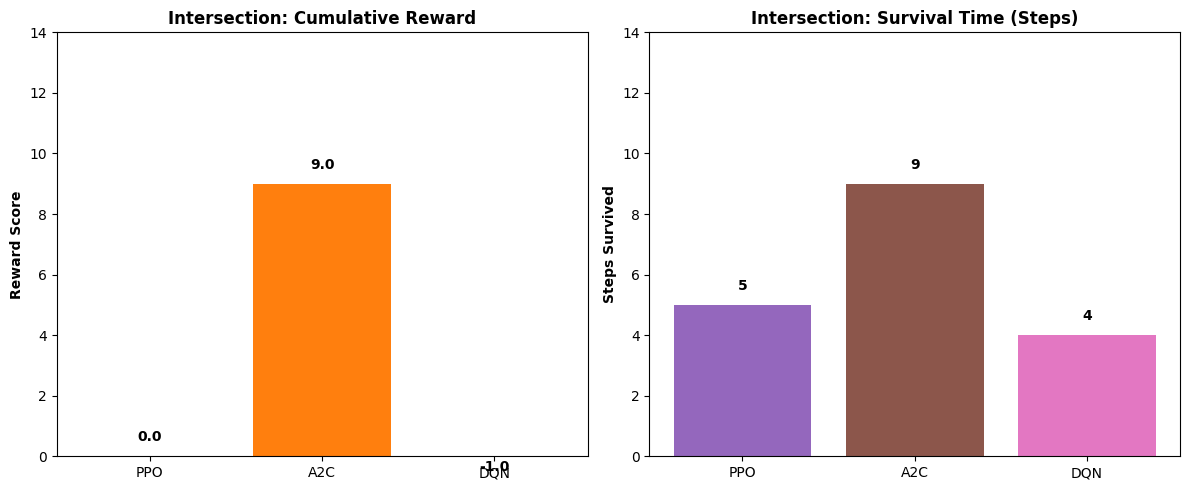

Intersection Analysis Charts safely generated and saved to /content/drive/MyDrive/defaultproject/chart_dual_intersection.png


In [19]:
# Providing a safety net to load from Drive if memory was wiped
JSON_PATH_INT = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_intersection.json"
if 'int_rewards_dict' not in locals() or not int_rewards_dict:
    print("Loading Baseline metrics from Drive...")
    with open(JSON_PATH_INT, "r") as infile_i:
        loaded_data_i = json.load(infile_i)
        int_rewards_dict = loaded_data_i["rewards"]
        int_steps_dict = loaded_data_i["steps"]

# Extracting uniquely named variables for the chart
algos_i_list = list(int_rewards_dict.keys())
rewards_i_list = list(int_rewards_dict.values())
steps_i_list = list(int_steps_dict.values())
fig_i, (ax1_i, ax2_i) = plt.subplots(1, 2, figsize=(12, 5))

# Plotting Cumulative Reward
ax1_i.bar(algos_i_list, rewards_i_list, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1_i.set_title('Intersection: Cumulative Reward', fontweight='bold')
ax1_i.set_ylabel('Reward Score', fontweight='bold')
if rewards_i_list:
    ax1_i.set_ylim(0, max(rewards_i_list) + 5)
for i, v in enumerate(rewards_i_list):
    ax1_i.text(i, v + 0.5, str(round(v, 2)), ha='center', fontweight='bold')

# Plotting Survival Time
ax2_i.bar(algos_i_list, steps_i_list, color=['#9467bd', '#8c564b', '#e377c2'])
ax2_i.set_title('Intersection: Survival Time (Steps)', fontweight='bold')
ax2_i.set_ylabel('Steps Survived', fontweight='bold')
if steps_i_list:
    ax2_i.set_ylim(0, max(steps_i_list) + 5)
for i, v in enumerate(steps_i_list):
    ax2_i.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()

# Saving the chart
CHART_PATH_INT = f"/content/drive/MyDrive/defaultproject/baseline_charts/chart_dual_intersection.png"
plt.savefig(CHART_PATH_INT)
plt.show()
print(f"Intersection Analysis Charts safely generated and saved to {CHART_PATH_INT}")

## Tuning Intersection DQN algorithm

In [20]:
# Defining unique variables for the Intersection Tuning experiment
ENV_NAME_TUNE_INT = "intersection-v0"
TOTAL_TIMESTEPS_TUNE_INT = 25000
SAVE_PATH_TUNE_INT = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/dqn_tuned_intersection"
CHECKPOINT_DIR_TUNE_INT = f"/content/drive/MyDrive/defaultproject/checkpoints/dqn_tuned_intersection"

# optimized combinations
tuned_int_dqn_params = {
    "learning_rate": 0.0005,
    "exploration_fraction": 0.5, # to force it to accidentally hit the brakes
    "batch_size": 256, # for stable learning of cross-traffic patterns
    "gamma": 0.95, #high enough to care about the future (waiting for a gap)
    "buffer_size": 100000,
    "verbose": 1}

# Training Phase
env_tune_int = gym.make(ENV_NAME_TUNE_INT)
if os.path.exists(SAVE_PATH_TUNE_INT + ".zip"):
    print("Tuned Intersection DQN is already trained. Skipping to evaluation...")
else:
    latest_checkpoint_tune_int = None
    steps_completed_tune_int = 0
    if os.path.exists(CHECKPOINT_DIR_TUNE_INT):
        checkpoints_tune_int = glob.glob(f"{CHECKPOINT_DIR_TUNE_INT}/dqn_tuned_intersection_backup_*_steps.zip")
        if checkpoints_tune_int:
            latest_checkpoint_tune_int = max(checkpoints_tune_int, key=os.path.getctime)
            try:
                steps_completed_tune_int = int(latest_checkpoint_tune_int.split('_')[-2])
            except:
                steps_completed_tune_int = 0
    # checking and resuming from certain steps where it crashed
    if latest_checkpoint_tune_int and steps_completed_tune_int > 0 and steps_completed_tune_int < TOTAL_TIMESTEPS_TUNE_INT:
        print(f"\nResuming Tuned Intersection DQN from step {steps_completed_tune_int}...")
        model_tune_int = DQN.load(latest_checkpoint_tune_int, env=env_tune_int)
        remaining_steps_tune_int = TOTAL_TIMESTEPS_TUNE_INT - steps_completed_tune_int
    else:
        print("\nInitializing Tuned Intersection DQN with aggressive exploration...")
        model_tune_int = DQN("MlpPolicy", env_tune_int, **tuned_int_dqn_params)
        remaining_steps_tune_int = TOTAL_TIMESTEPS_TUNE_INT
    # saving the checkpoints for every 5000 steps
    callback_tune_int = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR_TUNE_INT,
        name_prefix="dqn_tuned_intersection_backup")
    model_tune_int.learn(total_timesteps=remaining_steps_tune_int, callback=callback_tune_int, reset_num_timesteps=False)
    model_tune_int.save(SAVE_PATH_TUNE_INT)
    print("Tuned Intersection DQN training complete!")
env_tune_int.close()

Streaming output truncated to the last 5000 lines.
|    learning_rate    | 0.0005   |
|    loss             | 0.308    |
|    n_updates        | 3762     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.39     |
|    ep_rew_mean      | 4.03     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1864     |
|    fps              | 14       |
|    time_elapsed     | 1035     |
|    total_timesteps  | 15178    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.4      |
|    n_updates        | 3769     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.45     |
|    ep_rew_mean      | 4.11     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1868     |
|    fps              | 14       |
|   

## Evaluation & Video Backup

In [21]:
# Evaluation and Video Recording
eval_env_tune_int = gym.make(ENV_NAME_TUNE_INT, render_mode="rgb_array")
VIDEO_PATH_TUNE_INT = f"/content/drive/MyDrive/defaultproject/dqn_tuned_intersection_video.mp4"

print("\nRecording TUNED Intersection DQN...")
loaded_tuned_int_dqn = DQN.load(SAVE_PATH_TUNE_INT, env=eval_env_tune_int)
# Resetting the environment for a clean evaluation
obs_ti, info_ti = eval_env_tune_int.reset()
frames_ti = []
total_reward_ti = 0
episode_steps_ti = 0
done_ti = truncated_ti = False
# Running the episode to capture the tuned performance
while not (done_ti or truncated_ti):
    action_ti, _ = loaded_tuned_int_dqn.predict(obs_ti, deterministic=True)
    obs_ti, reward_ti, done_ti, truncated_ti, info_ti = eval_env_tune_int.step(action_ti)
    total_reward_ti += reward_ti
    episode_steps_ti += 1
    frame_ti = eval_env_tune_int.render()
    if frame_ti is not None:
        frames_ti.append(frame_ti)
# Saving the collected frames
imageio.mimsave(VIDEO_PATH_TUNE_INT, frames_ti, fps=15, macro_block_size=None)
print(f"Tuned Intersection Reward: {round(total_reward_ti, 2)} | Survived: {episode_steps_ti} steps")

# Saving Tuned Metrics
tuned_metrics_int = {"reward": total_reward_ti, "steps": episode_steps_ti}
METRICS_PATH_TUNE_INT = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_intersection_tuned.json"
with open(METRICS_PATH_TUNE_INT, "w") as outfile_ti:
    json.dump(tuned_metrics_int, outfile_ti)
display(Video(VIDEO_PATH_TUNE_INT, embed=True))
eval_env_tune_int.close()


Recording TUNED Intersection DQN...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Tuned Intersection Reward: 0.0 | Survived: 6 steps


## Tuning highway PPO algorithm

In [24]:
# Defining unique variables for the Highway PPO Tuning experiment
ENV_NAME_PPO_H = "highway-v0"
TOTAL_TIMESTEPS_PPO_H = 25000
SAVE_PATH_PPO_H = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/ppo_tuned_highway"
CHECKPOINT_DIR_PPO_H = f"/content/drive/MyDrive/defaultproject/checkpoints/ppo_tuned_highway"

# tuning parameters
tuned_ppo_h_params = {
    "learning_rate": 0.0003,
    "n_steps": 1024,
    "batch_size": 128,
    "gamma": 0.99,
    "ent_coef": 0.01, # Encourages more creative lane changes
    "verbose": 1}

# Training Phase
env_ppo_h = gym.make(ENV_NAME_PPO_H)
if os.path.exists(SAVE_PATH_PPO_H + ".zip"):
    print("Tuned Highway PPO is already trained. Skipping to evaluation...")
else:
    print("\nInitializing Tuned Highway PPO for maximum survival...")
    model_ppo_h = PPO("MlpPolicy", env_ppo_h, **tuned_ppo_h_params)
    # creating checkpoints for every 5000 steps
    callback_ppo_h = CheckpointCallback(
        save_freq=5000,
        save_path=CHECKPOINT_DIR_PPO_H,
        name_prefix="ppo_tuned_highway_backup")
    model_ppo_h.learn(total_timesteps=TOTAL_TIMESTEPS_PPO_H, callback=callback_ppo_h)
    model_ppo_h.save(SAVE_PATH_PPO_H)
    print("Tuned Highway PPO training complete!")
env_ppo_h.close()


Initializing Tuned Highway PPO for maximum survival...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 15.3     |
|    ep_rew_mean     | 11.8     |
| time/              |          |
|    fps             | 2        |
|    iterations      | 1        |
|    time_elapsed    | 393      |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 16.3        |
|    ep_rew_mean          | 12.4        |
| time/                   |             |
|    fps                  | 2           |
|    iterations           | 2           |
|    time_elapsed         | 795         |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.011195021 |
|    clip_fraction        | 0.106       |
|    

##  Evaluation & Video: Tuned Highway PPO

In [25]:
eval_env_ppo_h = gym.make(ENV_NAME_PPO_H, render_mode="rgb_array")
VIDEO_PATH_PPO_H = f"/content/drive/MyDrive/defaultproject/ppo_tuned_highway_video.mp4"

if not os.path.exists(SAVE_PATH_PPO_H + ".zip"):
    print("Missing Tuned PPO model. Please run the training cell first.")
else:
    print("\nRecording TUNED Highway PPO...")
    # Loading the newly trained tuned model
    loaded_tuned_ppo_h = PPO.load(SAVE_PATH_PPO_H, env=eval_env_ppo_h)
    # resetting environment for clear evaluation
    obs_ph, info_ph = eval_env_ppo_h.reset()
    frames_ph = []
    total_reward_ph = 0
    episode_steps_ph = 0
    done_ph = truncated_ph = False

    # Running the deterministic evaluation
    while not (done_ph or truncated_ph):
        action_ph, _ = loaded_tuned_ppo_h.predict(obs_ph, deterministic=True)
        obs_ph, reward_ph, done_ph, truncated_ph, info_ph = eval_env_ppo_h.step(action_ph)
        total_reward_ph += reward_ph
        episode_steps_ph += 1

        frame_ph = eval_env_ppo_h.render()
        if frame_ph is not None:
            frames_ph.append(frame_ph)

    # Saving the video to Google Drive
    imageio.mimsave(VIDEO_PATH_PPO_H, frames_ph, fps=15, macro_block_size=None)
    print(f"Tuned PPO Reward: {round(total_reward_ph, 2)} | Survived: {episode_steps_ph} steps")
    # Saving the JSON metrics securely
    tuned_metrics_ppo_h = {"reward": total_reward_ph, "steps": episode_steps_ph}
    METRICS_PATH_PPO_H = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_highway_ppo_tuned.json"
    with open(METRICS_PATH_PPO_H, "w") as f:
        json.dump(tuned_metrics_ppo_h, f)
    display(Video(VIDEO_PATH_PPO_H, embed=True)) # inline display
eval_env_ppo_h.close()


Recording TUNED Highway PPO...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Tuned PPO Reward: 29.36 | Survived: 40 steps


## Highway A2C (Tuning and evaluation)

In [5]:
ENV_NAME_A2C_H = "highway-v0"
TOTAL_TIMESTEPS_A2C_H = 25000
SAVE_PATH_A2C_H = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/a2c_tuned_highway"
CHECKPOINT_DIR_A2C_H = f"/content/drive/MyDrive/defaultproject/checkpoints/a2c_tuned_highway"
VIDEO_PATH_A2C_H = f"/content/drive/MyDrive/defaultproject/a2c_tuned_highway_video.mp4"
#tuning parameters
tuned_a2c_h_params = {
    "learning_rate": 0.0005,
    "n_steps": 10,            # Frequent updates suitable for highly dynamic traffic
    "gamma": 0.99,            # Prioritizing long-term rewards (avoiding future crashes)
    "ent_coef": 0.01,         # Preventing premature convergence
    "rms_prop_eps": 1e-5,     # Adjusting optimizer stability
    "verbose": 1}

env_a2c_h = gym.make(ENV_NAME_A2C_H)
# Checking if the tuned model is already fully trained
if os.path.exists(SAVE_PATH_A2C_H + ".zip"):
    print("Tuned Highway A2C is already trained. Skipping to evaluation...")
else:
    latest_checkpoint_a2c_h = None
    steps_completed_a2c_h = 0
    if os.path.exists(CHECKPOINT_DIR_A2C_H):
        checkpoints_a2c_h = glob.glob(f"{CHECKPOINT_DIR_A2C_H}/a2c_tuned_highway_backup_*_steps.zip")
        if checkpoints_a2c_h:
            latest_checkpoint_a2c_h = max(checkpoints_a2c_h, key=os.path.getctime)
            try: steps_completed_a2c_h = int(latest_checkpoint_a2c_h.split('_')[-2])
            except: steps_completed_a2c_h = 0
     # Deciding to resume from a backup OR start fresh
    if latest_checkpoint_a2c_h and steps_completed_a2c_h > 0 and steps_completed_a2c_h < TOTAL_TIMESTEPS_A2C_H:
        print(f"\nCrash detected! Resuming Tuned Highway A2C from step {steps_completed_a2c_h}...")
        model_a2c_h = A2C.load(latest_checkpoint_a2c_h, env=env_a2c_h)
        remaining_steps_a2c_h = TOTAL_TIMESTEPS_A2C_H - steps_completed_a2c_h
    else:
        print("\nInitializing Tuned Highway A2C...")
        model_a2c_h = A2C("MlpPolicy", env_a2c_h, **tuned_a2c_h_params)
        remaining_steps_a2c_h = TOTAL_TIMESTEPS_A2C_H
    # Creating a checkpoint callback to save the model every 5,000 steps
    callback_a2c_h = CheckpointCallback(save_freq=5000, save_path=CHECKPOINT_DIR_A2C_H, name_prefix="a2c_tuned_highway_backup")
    model_a2c_h.learn(total_timesteps=remaining_steps_a2c_h, callback=callback_a2c_h, reset_num_timesteps=False)
    model_a2c_h.save(SAVE_PATH_A2C_H)
env_a2c_h.close()


Initializing Tuned Highway A2C...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 23.9     |
|    ep_rew_mean        | 17.2     |
| time/                 |          |
|    fps                | 2        |
|    iterations         | 100      |
|    time_elapsed       | 382      |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -1.22    |
|    explained_variance | 0.00837  |
|    learning_rate      | 0.0005   |
|    n_updates          | 99       |
|    policy_loss        | 4.86     |
|    value_loss         | 16.4     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 28.5     |
|    ep_rew_mean        | 20.3     |
| time/                 |          |
|    fps                | 2        |
|    iterations    

In [7]:
eval_env_a2c_h = gym.make(ENV_NAME_A2C_H, render_mode="rgb_array")
print("\nRecording TUNED Highway A2C...")
# Loading the newly trained tuned A2C model
loaded_tuned_a2c_h = A2C.load(SAVE_PATH_A2C_H, env=eval_env_a2c_h)
# Resetting the environment
obs_ah, info_ah = eval_env_a2c_h.reset()
frames_ah, total_reward_ah, episode_steps_ah = [], 0, 0
done_ah = truncated_ah = False

while not (done_ah or truncated_ah):
  # Predicting the best action deterministically
    action_ah, _ = loaded_tuned_a2c_h.predict(obs_ah, deterministic=True)
    obs_ah, reward_ah, done_ah, truncated_ah, info_ah = eval_env_a2c_h.step(action_ah)
    total_reward_ah += reward_ah
    episode_steps_ah += 1
    frame_ah = eval_env_a2c_h.render()
    if frame_ah is not None: frames_ah.append(frame_ah)
# Saving the collected frames as an MP4 video
imageio.mimsave(VIDEO_PATH_A2C_H, frames_ah, fps=15, macro_block_size=None)
print(f"Tuned A2C Reward: {round(total_reward_ah, 2)} | Survived: {episode_steps_ah} steps")

with open(f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_highway_a2c_tuned.json", "w") as f:
    json.dump({"reward": total_reward_ah, "steps": episode_steps_ah}, f)
display(Video(VIDEO_PATH_A2C_H, embed=True))
eval_env_a2c_h.close()


Recording TUNED Highway A2C...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Tuned A2C Reward: 29.36 | Survived: 40 steps


## Roundabout tuning (PPO & A2C combined)

In [8]:
ENV_R = "roundabout-v0"
TOTAL_TIMESTEPS_R = 25000
# High entropy (0.05) to force exploration of yielding behaviors.
# Gamma (0.95) to prioritize near-term future rewards (timing the merge).
tuned_params_r = {
    "PPO": {"learning_rate": 0.0003, "n_steps": 1024, "batch_size": 128, "gamma": 0.95, "ent_coef": 0.05, "verbose": 1},
    "A2C": {"learning_rate": 0.0005, "n_steps": 10, "gamma": 0.95, "ent_coef": 0.05, "rms_prop_eps": 1e-5, "verbose": 1}}
# Grouping algorithms to execute training sequentially
algos_r = {"PPO": PPO, "A2C": A2C}
env_train_r = gym.make(ENV_R)
eval_env_r = gym.make(ENV_R, render_mode="rgb_array")

for name, algo_class in algos_r.items():
    SAVE_PATH = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/{name.lower()}_tuned_roundabout"
    CHECKPOINT_DIR = f"/content/drive/MyDrive/defaultproject/checkpoints/{name.lower()}_tuned_roundabout"
    VIDEO_PATH = f"/content/drive/MyDrive/defaultproject/{name.lower()}_tuned_roundabout_video.mp4"
    METRICS_PATH = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_roundabout_{name.lower()}_tuned.json"

    if os.path.exists(SAVE_PATH + ".zip"):
        print(f"\nTuned Roundabout {name} is already trained. Skipping to evaluation...")
    else:
      # Searching for mid-training backups in case Colab crashed
        latest_cp = None
        steps_comp = 0
        if os.path.exists(CHECKPOINT_DIR):
            cps = glob.glob(f"{CHECKPOINT_DIR}/{name.lower()}_tuned_roundabout_backup_*_steps.zip")
            if cps:
                latest_cp = max(cps, key=os.path.getctime)
                try: steps_comp = int(latest_cp.split('_')[-2])
                except: steps_comp = 0
         # Deciding to resume from a backup OR start fresh
        if latest_cp and steps_comp > 0 and steps_comp < TOTAL_TIMESTEPS_R:
            print(f"\nCrash detected! Resuming Tuned Roundabout {name} from step {steps_comp}...")
            model = algo_class.load(latest_cp, env=env_train_r)
            rem_steps = TOTAL_TIMESTEPS_R - steps_comp
        else:
            print(f"\nInitializing Tuned Roundabout {name}...")
            model = algo_class("MlpPolicy", env_train_r, **tuned_params_r[name])
            rem_steps = TOTAL_TIMESTEPS_R

        callback = CheckpointCallback(save_freq=5000, save_path=CHECKPOINT_DIR, name_prefix=f"{name.lower()}_tuned_roundabout_backup")
        # Executing the training phase
        model.learn(total_timesteps=rem_steps, callback=callback, reset_num_timesteps=False)
        model.save(SAVE_PATH)

    # evaluatingf and saving
    print(f"Evaluating Tuned {name} on Roundabout...")
    loaded_model = algo_class.load(SAVE_PATH, env=eval_env_r)
    obs, info = eval_env_r.reset()
    frames, rew, steps = [], 0, 0
    done = trunc = False
    # Running the episode to capture the tuned performance
    while not (done or trunc):
        act, _ = loaded_model.predict(obs, deterministic=True)
        obs, r, done, trunc, _ = eval_env_r.step(act)
        rew += r
        steps += 1
        f = eval_env_r.render()
        if f is not None: frames.append(f)
     # Saving the tuned performance video
    imageio.mimsave(VIDEO_PATH, frames, fps=15, macro_block_size=None)
    print(f"Tuned {name} Reward: {round(rew, 2)} | Survived: {steps} steps")
    with open(METRICS_PATH, "w") as f: json.dump({"reward": rew, "steps": steps}, f)
    display(Video(VIDEO_PATH, embed=True))
env_train_r.close()
eval_env_r.close()


Initializing Tuned Roundabout PPO...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 8.51     |
|    ep_rew_mean     | 7.28     |
| time/              |          |
|    fps             | 21       |
|    iterations      | 1        |
|    time_elapsed    | 47       |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 9.31        |
|    ep_rew_mean          | 7.92        |
| time/                   |             |
|    fps                  | 21          |
|    iterations           | 2           |
|    time_elapsed         | 95          |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.009217842 |
|    clip_fraction        | 0.0514      |
|    clip_range        


Initializing Tuned Roundabout A2C...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 10.1     |
|    ep_rew_mean        | 8.57     |
| time/                 |          |
|    fps                | 21       |
|    iterations         | 100      |
|    time_elapsed       | 47       |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -1.49    |
|    explained_variance | 0.569    |
|    learning_rate      | 0.0005   |
|    n_updates          | 99       |
|    policy_loss        | 0.889    |
|    value_loss         | 0.537    |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 10.6     |
|    ep_rew_mean        | 8.99     |
| time/                 |          |
|    fps                | 21       |
|    iterations 

## Intersection Tuning (PPO & A2C)

In [9]:
ENV_I = "intersection-v0"
TOTAL_TIMESTEPS_I = 25000

# tuning- High gamma (0.99) to force it to look far into the future like wait for cars to pass.
tuned_params_i = {
    "PPO": {"learning_rate": 0.0003, "n_steps": 1024, "batch_size": 128, "gamma": 0.99, "ent_coef": 0.05, "verbose": 1},
    "A2C": {"learning_rate": 0.0005, "n_steps": 10, "gamma": 0.99, "ent_coef": 0.05, "rms_prop_eps": 1e-5, "verbose": 1}}
# Grouping algorithms to execute training sequentially
algos_i = {"PPO": PPO, "A2C": A2C}
env_train_i = gym.make(ENV_I)
eval_env_i = gym.make(ENV_I, render_mode="rgb_array")
# Looping through each algorithm for crash-proof training and evaluation
for name, algo_class in algos_i.items():
    SAVE_PATH = f"/content/drive/MyDrive/defaultproject/tuned_checkpoints/{name.lower()}_tuned_intersection"
    CHECKPOINT_DIR = f"/content/drive/MyDrive/defaultproject/checkpoints/{name.lower()}_tuned_intersection"
    VIDEO_PATH = f"/content/drive/MyDrive/defaultproject/{name.lower()}_tuned_intersection_video.mp4"
    METRICS_PATH = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_intersection_{name.lower()}_tuned.json"

    if os.path.exists(SAVE_PATH + ".zip"):
        print(f"\nTuned Intersection {name} is already trained. Skipping to evaluation...")
    else:
        latest_cp = None
        steps_comp = 0
        if os.path.exists(CHECKPOINT_DIR):
            cps = glob.glob(f"{CHECKPOINT_DIR}/{name.lower()}_tuned_intersection_backup_*_steps.zip")
            if cps:
                latest_cp = max(cps, key=os.path.getctime)
                try: steps_comp = int(latest_cp.split('_')[-2])
                except: steps_comp = 0
         # Deciding to resume from a backup OR start fresh
        if latest_cp and steps_comp > 0 and steps_comp < TOTAL_TIMESTEPS_I:
            print(f"\nCrash detected! Resuming Tuned Intersection {name} from step {steps_comp}...")
            model = algo_class.load(latest_cp, env=env_train_i)
            rem_steps = TOTAL_TIMESTEPS_I - steps_comp
        else:
            print(f"\nInitializing Tuned Intersection {name}...")
            model = algo_class("MlpPolicy", env_train_i, **tuned_params_i[name])
            rem_steps = TOTAL_TIMESTEPS_I
         # saving every 5000 checkpoints
        callback = CheckpointCallback(save_freq=5000, save_path=CHECKPOINT_DIR, name_prefix=f"{name.lower()}_tuned_intersection_backup")
        model.learn(total_timesteps=rem_steps, callback=callback, reset_num_timesteps=False)
        model.save(SAVE_PATH)

    # evaluating and saving
    print(f"Evaluating Tuned {name} on Intersection...")
    loaded_model = algo_class.load(SAVE_PATH, env=eval_env_i)
    obs, info = eval_env_i.reset()
    frames, rew, steps = [], 0, 0
    done = trunc = False
    # Running the episode to capture the tuned performance deterministically
    while not (done or trunc):
        act, _ = loaded_model.predict(obs, deterministic=True)
        obs, r, done, trunc, _ = eval_env_i.step(act)
        rew += r
        steps += 1
        f = eval_env_i.render()
        if f is not None: frames.append(f)
    # Saving the tuned performance video
    imageio.mimsave(VIDEO_PATH, frames, fps=15, macro_block_size=None)
    print(f"Tuned {name} Reward: {round(rew, 2)} | Survived: {steps} steps")
    with open(METRICS_PATH, "w") as f: json.dump({"reward": rew, "steps": steps}, f)
    display(Video(VIDEO_PATH, embed=True))
env_train_i.close()
eval_env_i.close()


Initializing Tuned Intersection PPO...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 9.69     |
|    ep_rew_mean     | 1.47     |
| time/              |          |
|    fps             | 13       |
|    iterations      | 1        |
|    time_elapsed    | 77       |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 9.31        |
|    ep_rew_mean          | 1.73        |
| time/                   |             |
|    fps                  | 13          |
|    iterations           | 2           |
|    time_elapsed         | 155         |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.013132086 |
|    clip_fraction        | 0.105       |
|    clip_range      


Initializing Tuned Intersection A2C...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 8.17     |
|    ep_rew_mean        | 3.22     |
| time/                 |          |
|    fps                | 14       |
|    iterations         | 100      |
|    time_elapsed       | 68       |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -0.69    |
|    explained_variance | 0.265    |
|    learning_rate      | 0.0005   |
|    n_updates          | 99       |
|    policy_loss        | 0.439    |
|    value_loss         | 14.1     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 7.63     |
|    ep_rew_mean        | 4.86     |
| time/                 |          |
|    fps                | 14       |
|    iteration

## overall final comparison charts

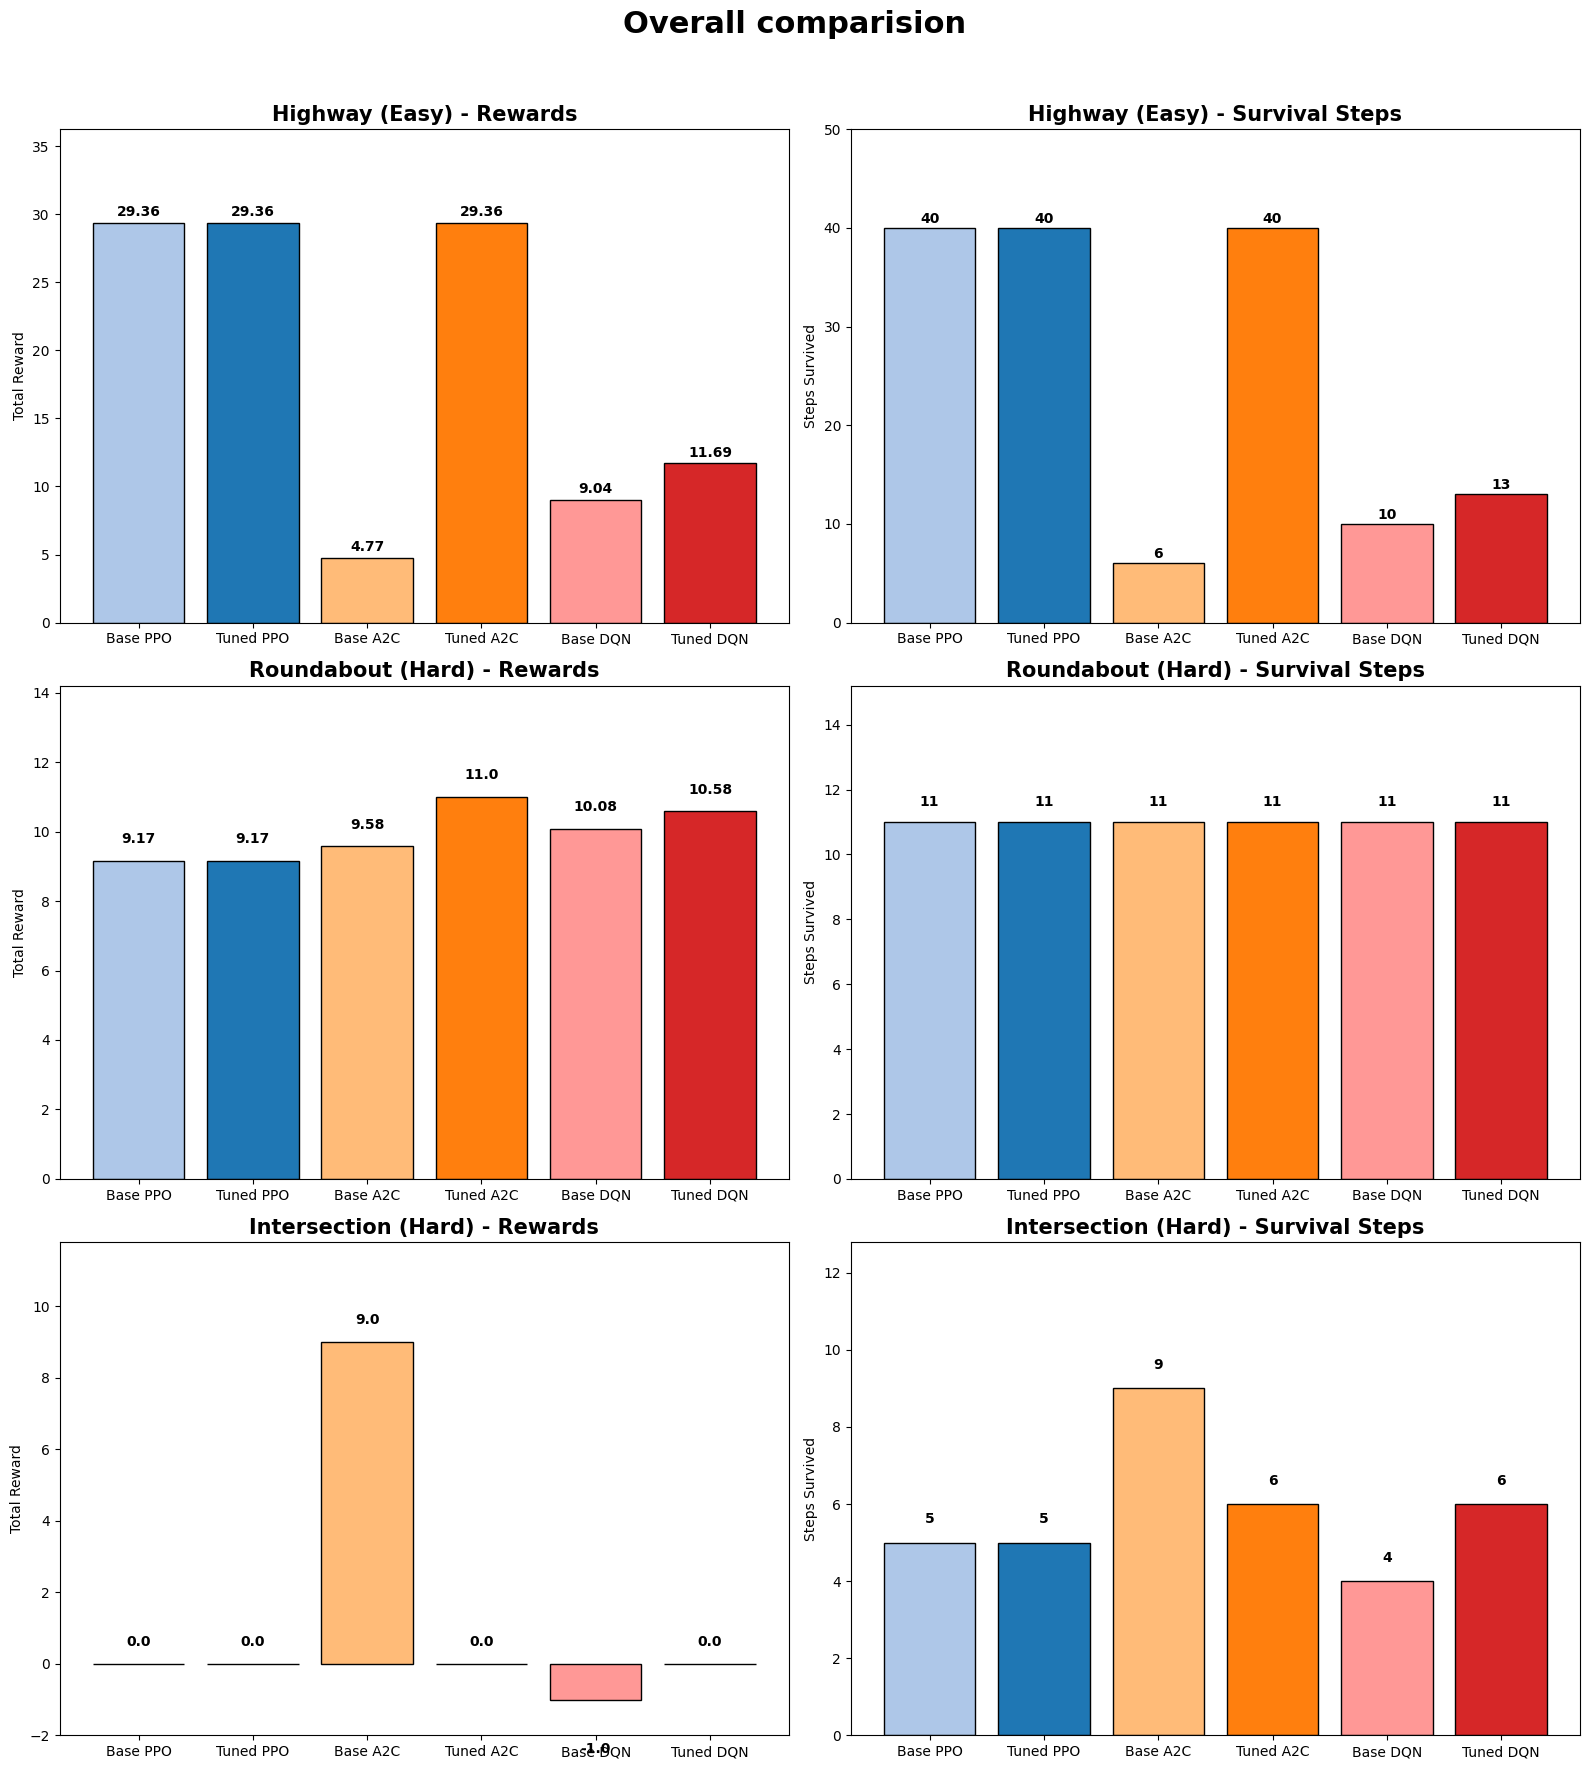


overall charts generated and saved to /content/drive/MyDrive/defaultproject/all_charts_ultimate.png


In [10]:
def load_all_metrics(env_name):
    # Loading Baselines
    base_path = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_{env_name}.json"
    base_data = {"rewards": {"PPO": 0, "A2C": 0, "DQN": 0}, "steps": {"PPO": 0, "A2C": 0, "DQN": 0}}
    if os.path.exists(base_path):
        with open(base_path, "r") as f:
            loaded = json.load(f)
            base_data["rewards"].update(loaded.get("rewards", {}))
            base_data["steps"].update(loaded.get("steps", {}))

    # Loading Tuned Models
    tuned_data = {"rewards": {"PPO": 0, "A2C": 0, "DQN": 0}, "steps": {"PPO": 0, "A2C": 0, "DQN": 0}}
    for algo in ["PPO", "A2C", "DQN"]:
        if algo == "DQN":
            p1 = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_{env_name}_tuned.json"
            p2 = f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_{env_name}_best.json"
            paths = [p1, p2]
        else:
            paths = [f"/content/drive/MyDrive/defaultproject/json_metrics/metrics_{env_name}_{algo.lower()}_tuned.json"]

        for p in paths:
            if os.path.exists(p):
                with open(p, "r") as f:
                    data = json.load(f)
                    tuned_data["rewards"][algo] = data.get("reward", data.get("rewards", 0))
                    tuned_data["steps"][algo] = data.get("steps", 0)
                break
    return base_data, tuned_data

envs = ["highway", "roundabout", "intersection"]
titles = ["Highway (Easy)", "Roundabout (Hard)", "Intersection (Hard)"]

fig_master, axes_master = plt.subplots(3, 2, figsize=(16, 18))
fig_master.suptitle("Overall comparision", fontsize=22, fontweight='bold', y=0.98)

# Base vs Tuned for each algorithm
labels = ['Base PPO', 'Tuned PPO', 'Base A2C', 'Tuned A2C', 'Base DQN', 'Tuned DQN']
# Paired Colors: Light/Dark Blue (PPO), Light/Dark Orange (A2C), Light/Dark Red (DQN)
colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e', '#ff9896', '#d62728']

for i, env in enumerate(envs):
    base, tuned = load_all_metrics(env)

    # Interleaving Base and Tuned data for direct side-by-side comparison
    env_rews = [
        base["rewards"].get("PPO", 0), tuned["rewards"].get("PPO", 0),
        base["rewards"].get("A2C", 0), tuned["rewards"].get("A2C", 0),
        base["rewards"].get("DQN", 0), tuned["rewards"].get("DQN", 0)
    ]
    env_stps = [
        base["steps"].get("PPO", 0), tuned["steps"].get("PPO", 0),
        base["steps"].get("A2C", 0), tuned["steps"].get("A2C", 0),
        base["steps"].get("DQN", 0), tuned["steps"].get("DQN", 0)
    ]

    #  plotting
    ax_rew = axes_master[i, 0]
    ax_rew.bar(labels, env_rews, color=colors, edgecolor='black')
    ax_rew.set_title(f"{titles[i]} - Rewards", fontweight='bold', fontsize=15)
    ax_rew.set_ylabel("Total Reward")

    y_min_rew = min(0, min(env_rews) - 1)
    y_max_rew = max(env_rews) + (max(env_rews) * 0.2) + 1
    ax_rew.set_ylim(y_min_rew, y_max_rew)
    # Adding data labels above/below the bars
    for j, v in enumerate(env_rews):
        offset = 0.5 if v >= 0 else -1.5
        ax_rew.text(j, v + offset, str(round(v, 2)), ha='center', fontweight='bold')
    ax_stp = axes_master[i, 1]
    ax_stp.bar(labels, env_stps, color=colors, edgecolor='black')
    ax_stp.set_title(f"{titles[i]} - Survival Steps", fontweight='bold', fontsize=15)
    ax_stp.set_ylabel("Steps Survived")
    ax_stp.set_ylim(0, max(env_stps) + (max(env_stps) * 0.2) + 2)

    for j, v in enumerate(env_stps):
        ax_stp.text(j, v + 0.5, str(int(v)), ha='center', fontweight='bold')
# Formatting and Saving
plt.tight_layout(rect=[0, 0, 1, 0.96])
MASTER_CHART_PATH = "/content/drive/MyDrive/defaultproject/all_charts_ultimate.png"
plt.savefig(MASTER_CHART_PATH, dpi=300)
plt.show()
print(f"\noverall charts generated and saved to {MASTER_CHART_PATH}")